In [ ]:
#1. ІМПОРТ БІБЛІОТЕК
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.stats import probplot, shapiro
import warnings
warnings.filterwarnings('ignore')


In [19]:
print("=" * 80)
print("ЗАВАНТАЖЕННЯ ТА РОЗВІДКОВИЙ АНАЛІЗ ДАНИХ")
print("=" * 80)

# Завантаження даних 
df = pd.read_csv('Student_Performance.csv')

print("\n Перші 5 рядків датасету:")
print(df.head())

print("\n Інформація про датасет:")
print(df.info())

print("\n Статистичний опис:")
print(df.describe())

print("\n Перевірка на пропущені значення:")
print(df.isnull().sum())

ЗАВАНТАЖЕННЯ ТА РОЗВІДКОВИЙ АНАЛІЗ ДАНИХ

 Перші 5 рядків датасету:
   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  

 Інформація про датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 colu

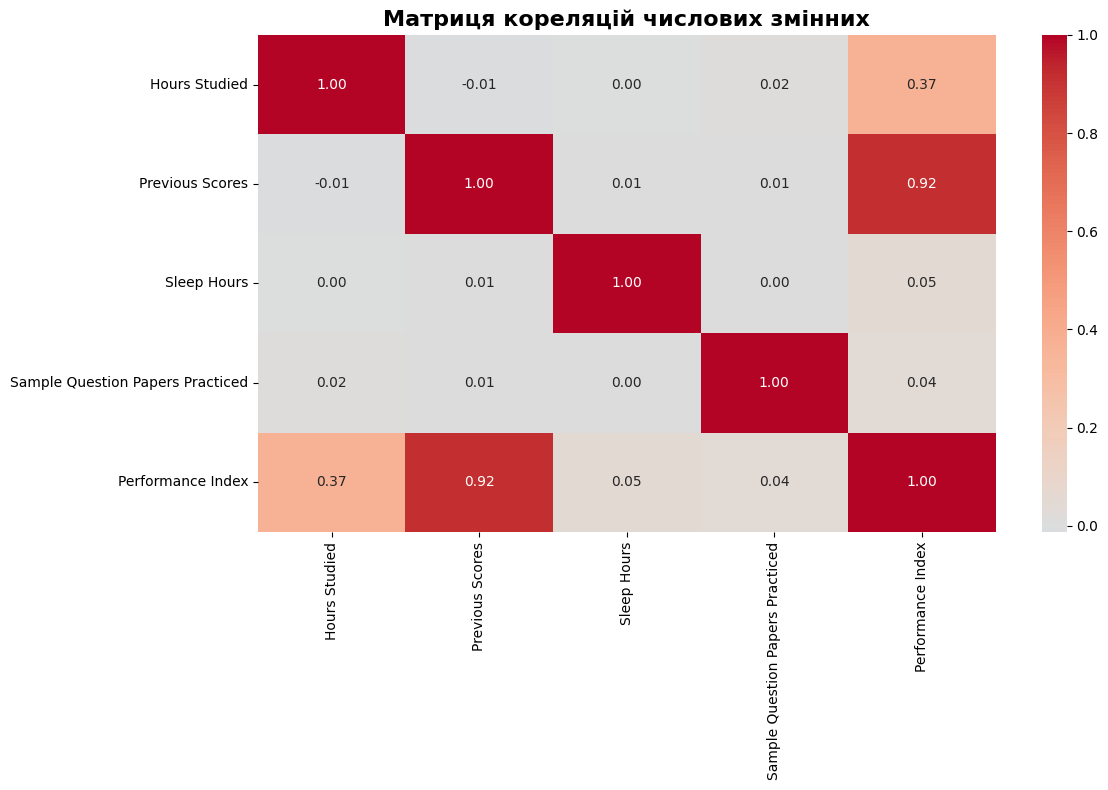


 Кореляція з Performance Index:
Performance Index                   1.000000
Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Name: Performance Index, dtype: float64


In [20]:
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матриця кореляцій числових змінних', fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Кореляція з Performance Index:")
print(correlation_matrix['Performance Index'].sort_values(ascending=False))


ПІДГОТОВКА ДАНИХ

 Категоріальна змінна 'Extracurricular Activities' закодована

 Розмірність даних:
   Ознаки (X): (10000, 5)
   Цільова змінна (y): (10000,)

 Список ознак: ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']

 Поділ даних:
   Train: 8000 зразків
   Test: 2000 зразків

 Після стандартизації та додавання intercept:
   X_train_final: (8000, 6)
   X_test_final: (2000, 6)

РЕАЛІЗАЦІЯ ГРАДІЄНТНОГО СПУСКУ

 Гіперпараметри:
   Learning rate: 0.01
   Epochs: 1000
   Початкові ваги: [0. 0. 0.]... (всього 6 параметрів)

 Початок навчання...
   Епоха    0/1000: MSE = 3292.539047
   Епоха  100/1000: MSE = 62.180443
   Епоха  200/1000: MSE = 5.193778
   Епоха  300/1000: MSE = 4.187826
   Епоха  400/1000: MSE = 4.170056
   Епоха  500/1000: MSE = 4.169742
   Епоха  600/1000: MSE = 4.169736
   Епоха  700/1000: MSE = 4.169736
   Епоха  800/1000: MSE = 4.169736
   Епоха  900/1000: MSE = 4.169736
   Епоха  999/1000: MSE 

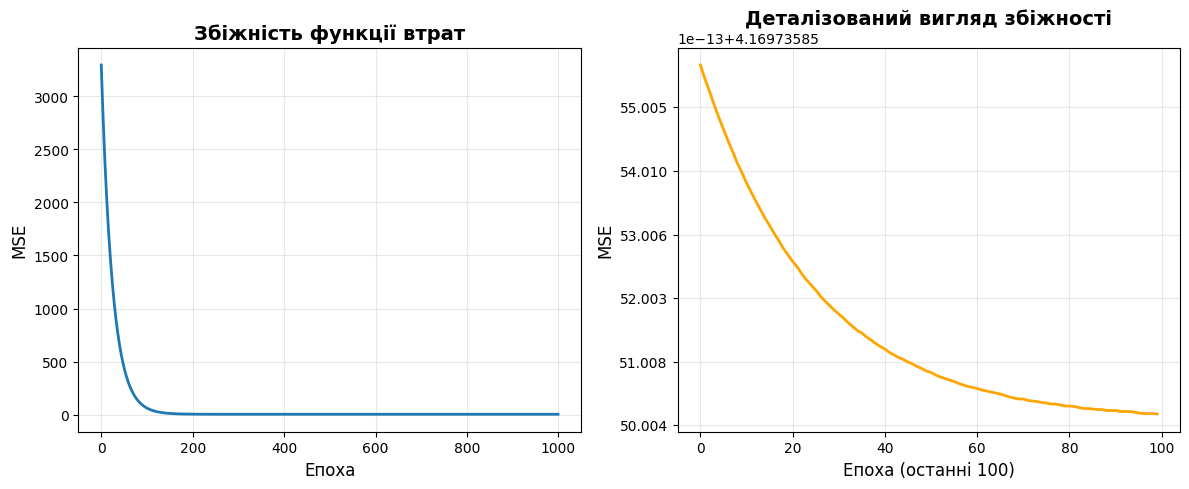

In [21]:
print("\n" + "=" * 80)
print("ПІДГОТОВКА ДАНИХ")
print("=" * 80)

# Обробка категоріальних змінних
if 'Extracurricular Activities' in df.columns:
    df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'No': 0, 'Yes': 1})
    print("\n Категоріальна змінна 'Extracurricular Activities' закодована")

# Вибір ознак та цільової змінної
X = df.drop('Performance Index', axis=1)
y = df['Performance Index'].values

print(f"\n Розмірність даних:")
print(f"   Ознаки (X): {X.shape}")
print(f"   Цільова змінна (y): {y.shape}")
print(f"\n Список ознак: {list(X.columns)}")

# Поділ на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n Поділ даних:")
print(f"   Train: {X_train.shape[0]} зразків")
print(f"   Test: {X_test.shape[0]} зразків")

# Стандартизація
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Додавання стовпчика одиниць для intercept
X_train_final = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_final = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

print(f"\n Після стандартизації та додавання intercept:")
print(f"   X_train_final: {X_train_final.shape}")
print(f"   X_test_final: {X_test_final.shape}")

# ==================== 4. ГРАДІЄНТНИЙ СПУСК ====================
print("\n" + "=" * 80)
print("РЕАЛІЗАЦІЯ ГРАДІЄНТНОГО СПУСКУ")
print("=" * 80)

def compute_cost(X, y, beta):
    """Обчислення функції втрат (MSE)"""
    m = len(y)
    predictions = X.dot(beta)
    errors = predictions - y
    mse = (1 / m) * np.sum(errors ** 2)
    return mse

def gradient_descent(X, y, beta, learning_rate, epochs, verbose=True):
    """Реалізація градієнтного спуску"""
    cost_history = []
    m = len(y)
    
    for epoch in range(epochs):
        # Обчислення передбачень
        predictions = X.dot(beta)
        
        # Обчислення помилки
        errors = predictions - y
        
        # Обчислення градієнта (похідна MSE за beta)
        gradient = (2 / m) * X.T.dot(errors)
        
        # Оновлення ваг
        beta = beta - learning_rate * gradient
        
        # Збереження поточного MSE
        cost = compute_cost(X, y, beta)
        cost_history.append(cost)
        
        # Виведення прогресу
        if verbose and (epoch % 100 == 0 or epoch == epochs - 1):
            print(f"   Епоха {epoch:4d}/{epochs}: MSE = {cost:.6f}")
    
    return beta, cost_history

# Ініціалізація параметрів
beta = np.zeros(X_train_final.shape[1])
learning_rate = 0.01
epochs = 1000

print(f"\n Гіперпараметри:")
print(f"   Learning rate: {learning_rate}")
print(f"   Epochs: {epochs}")
print(f"   Початкові ваги: {beta[:3]}... (всього {len(beta)} параметрів)")

# Навчання моделі
print(f"\n Початок навчання...")
beta_final, cost_history = gradient_descent(
    X_train_final, y_train, beta, learning_rate, epochs
)

print(f"\n Навчання завершено!")
print(f"\n Фінальні коефіцієнти β:")
print(f"   β₀ (intercept): {beta_final[0]:.6f}")
for i, col in enumerate(X.columns, 1):
    print(f"   β{i} ({col}): {beta_final[i]:.6f}")

# Візуалізація навчання
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cost_history, linewidth=2)
plt.xlabel('Епоха', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Збіжність функції втрат', fontsize=14, weight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(cost_history[-100:], linewidth=2, color='orange')
plt.xlabel('Епоха (останні 100)', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('Деталізований вигляд збіжності', fontsize=14, weight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_convergence.png', dpi=300, bbox_inches='tight')
plt.show()


In [22]:
# ==================== 5. ОЦІНКА МОДЕЛІ ====================
print("\n" + "=" * 80)
print("ОЦІНКА ЯКОСТІ МОДЕЛІ НА ТЕСТОВИХ ДАНИХ")
print("=" * 80)

# Прогнозування
y_pred_train = X_train_final.dot(beta_final)
y_pred_test = X_test_final.dot(beta_final)

# Розрахунок метрик
mse_train = np.mean((y_train - y_pred_train) ** 2)
mse_test = np.mean((y_test - y_pred_test) ** 2)

r2_train = 1 - (np.sum((y_train - y_pred_train) ** 2) / 
                np.sum((y_train - np.mean(y_train)) ** 2))
r2_test = 1 - (np.sum((y_test - y_pred_test) ** 2) / 
               np.sum((y_test - np.mean(y_test)) ** 2))

rmse_test = np.sqrt(mse_test)
mae_test = np.mean(np.abs(y_test - y_pred_test))

print(f"\n Метрики на тренувальній вибірці:")
print(f"   MSE:  {mse_train:.6f}")
print(f"   R²:   {r2_train:.6f}")

print(f"\n Метрики на тестовій вибірці:")
print(f"   MSE:  {mse_test:.6f}")
print(f"   RMSE: {rmse_test:.6f}")
print(f"   MAE:  {mae_test:.6f}")
print(f"   R²:   {r2_test:.6f}")


ОЦІНКА ЯКОСТІ МОДЕЛІ НА ТЕСТОВИХ ДАНИХ

 Метрики на тренувальній вибірці:
   MSE:  4.169736
   R²:   0.988690

 Метрики на тестовій вибірці:
   MSE:  4.082628
   RMSE: 2.020552
   MAE:  1.611121
   R²:   0.988983



 Порівняння з бейзлайном (середнє значення):
   Baseline MSE: 370.773038
   Покращення:   98.90%


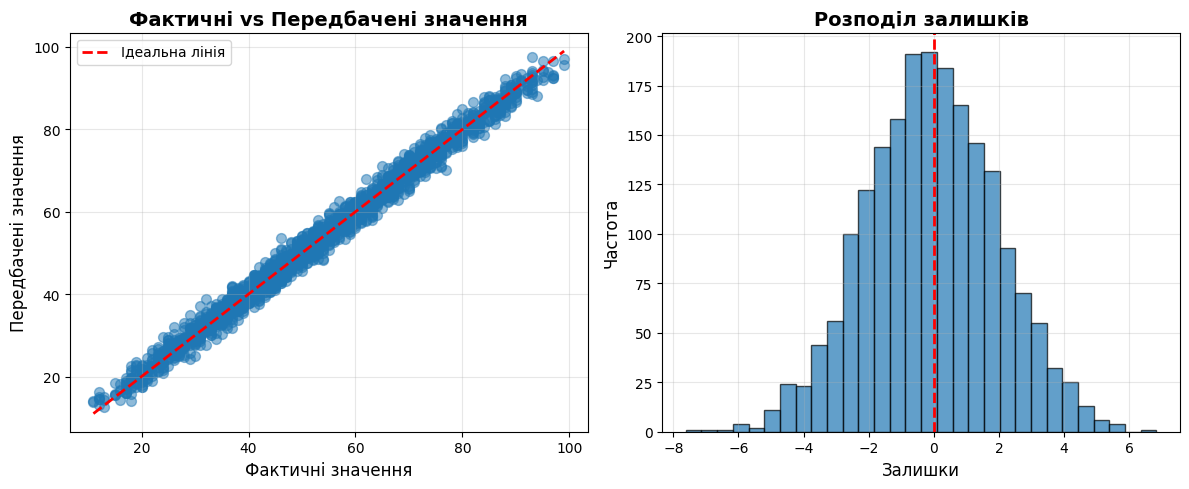

In [23]:
# Порівняння з бейзлайном
baseline_mse = np.mean((y_test - np.mean(y_train)) ** 2)
improvement = ((baseline_mse - mse_test) / baseline_mse) * 100

print(f"\n Порівняння з бейзлайном (середнє значення):")
print(f"   Baseline MSE: {baseline_mse:.6f}")
print(f"   Покращення:   {improvement:.2f}%")

# Візуалізація прогнозів
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_test, alpha=0.5, s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Ідеальна лінія')
plt.xlabel('Фактичні значення', fontsize=12)
plt.ylabel('Передбачені значення', fontsize=12)
plt.title('Фактичні vs Передбачені значення', fontsize=14, weight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
residuals_test = y_test - y_pred_test
plt.hist(residuals_test, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Залишки', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Розподіл залишків', fontsize=14, weight='bold')
plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


ПЕРЕВІРКА ШЕСТИ КЛАСИЧНИХ ПРИПУЩЕНЬ МНК

1️⃣ ПРИПУЩЕННЯ ЛІНІЙНОСТІ
------------------------------------------------------------


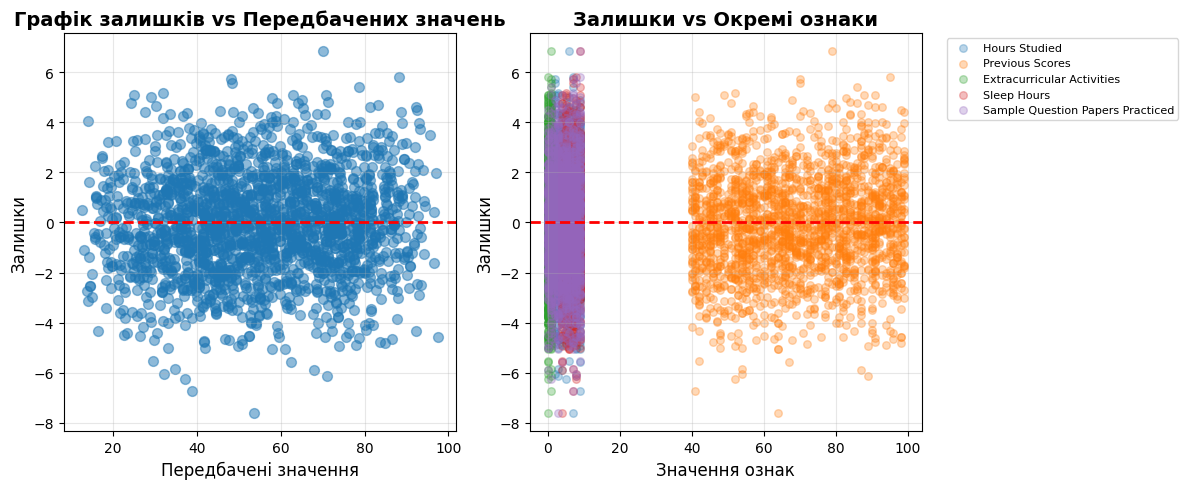

 Коефіцієнт нелінійності: 0.000015
   ✓ Лінійність виконується

2 ПРИПУЩЕННЯ ВІДСУТНОСТІ МУЛЬТИКОЛІНЕАРНОСТІ
------------------------------------------------------------

 Variance Inflation Factor (VIF):
                          Ознака      VIF
                   Hours Studied 1.000387
                 Previous Scores 1.000243
      Extracurricular Activities 1.000428
                     Sleep Hours 1.000461
Sample Question Papers Practiced 1.000320

 Мультиколінеарність відсутня (всі VIF < 5)


In [24]:
# ==================== 6. ПЕРЕВІРКА ПРИПУЩЕНЬ МНК ====================
print("\n" + "=" * 80)
print("ПЕРЕВІРКА ШЕСТИ КЛАСИЧНИХ ПРИПУЩЕНЬ МНК")
print("=" * 80)

residuals = y_test - y_pred_test

# ПРИПУЩЕННЯ 1: Лінійність зв'язку
print("\n1️⃣ ПРИПУЩЕННЯ ЛІНІЙНОСТІ")
print("-" * 60)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_test, residuals, alpha=0.5, s=50)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Передбачені значення', fontsize=12)
plt.ylabel('Залишки', fontsize=12)
plt.title('Графік залишків vs Передбачених значень', fontsize=14, weight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for i, col in enumerate(X.columns):
    plt.scatter(X_test.iloc[:, i], residuals, alpha=0.3, s=30, label=col)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Значення ознак', fontsize=12)
plt.ylabel('Залишки', fontsize=12)
plt.title('Залишки vs Окремі ознаки', fontsize=14, weight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('linearity_check.png', dpi=300, bbox_inches='tight')
plt.show()

residual_pattern = np.polyfit(y_pred_test, residuals, 2)[0]
print(f" Коефіцієнт нелінійності: {abs(residual_pattern):.6f}")
print(f"   {'✓ Лінійність виконується' if abs(residual_pattern) < 0.01 else '✗ Можлива нелінійність'}")

# ПРИПУЩЕННЯ 2: Відсутність мультиколінеарності (VIF)
print("\n2 ПРИПУЩЕННЯ ВІДСУТНОСТІ МУЛЬТИКОЛІНЕАРНОСТІ")
print("-" * 60)

def calculate_vif(X):
    """Розрахунок VIF для кожної ознаки"""
    vif_data = []
    for i in range(X.shape[1]):
        X_i = X[:, i]
        X_rest = np.delete(X, i, axis=1)
        
        # Регресія i-ої змінної на всі інші
        beta_vif = np.linalg.lstsq(X_rest, X_i, rcond=None)[0]
        y_pred_vif = X_rest.dot(beta_vif)
        
        # R² для цієї регресії
        ss_res = np.sum((X_i - y_pred_vif) ** 2)
        ss_tot = np.sum((X_i - np.mean(X_i)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        
        # VIF
        vif = 1 / (1 - r2) if r2 < 0.9999 else np.inf
        vif_data.append(vif)
    
    return vif_data

vif_values = calculate_vif(X_train_scaled)
vif_df = pd.DataFrame({
    'Ознака': X.columns,
    'VIF': vif_values
})

print("\n Variance Inflation Factor (VIF):")
print(vif_df.to_string(index=False))
print(f"\n{' Мультиколінеарність відсутня (всі VIF < 5)' if max(vif_values) < 5 else ' Можлива мультиколінеарність (деякі VIF ≥ 5)'}")


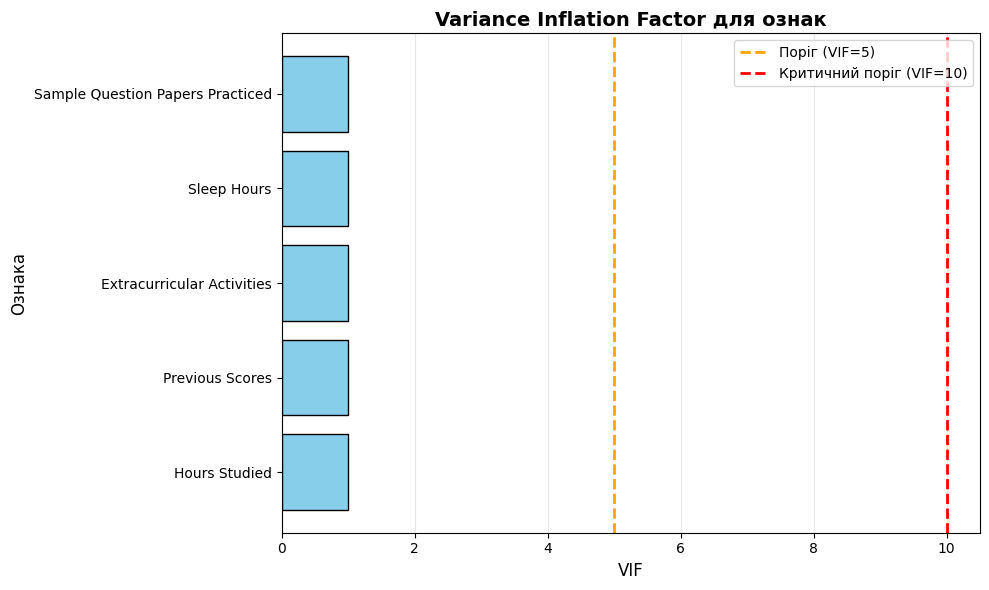


 ПРИПУЩЕННЯ НОРМАЛЬНОСТІ ЗАЛИШКІВ
------------------------------------------------------------


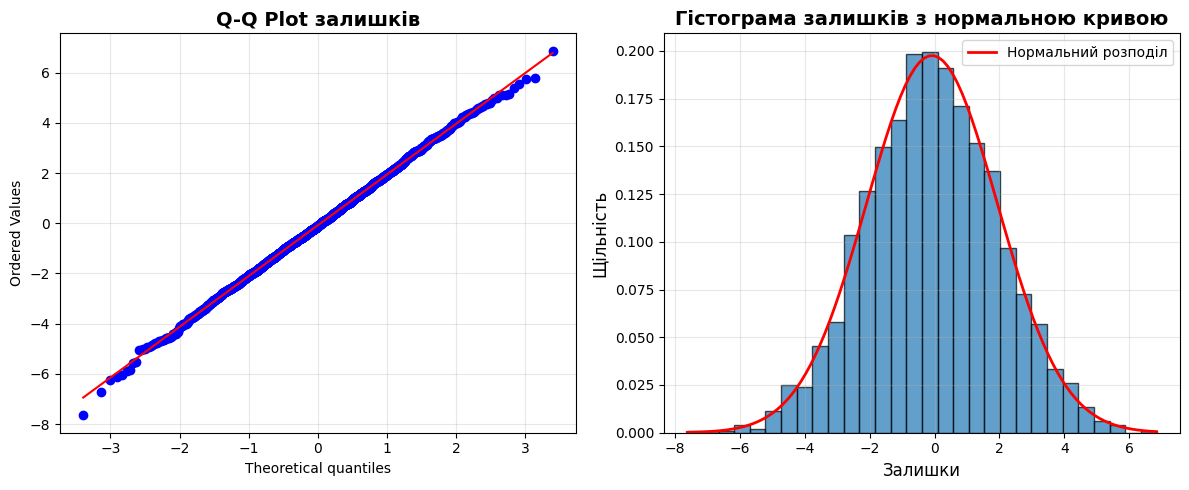


 Тест Шапіро-Вілка:
   Статистика: 0.999610
   p-value:    0.975150
    Залишки мають нормальний розподіл (p > 0.05)

 ПРИПУЩЕННЯ ГОМОСКЕДАСТИЧНОСТІ
------------------------------------------------------------


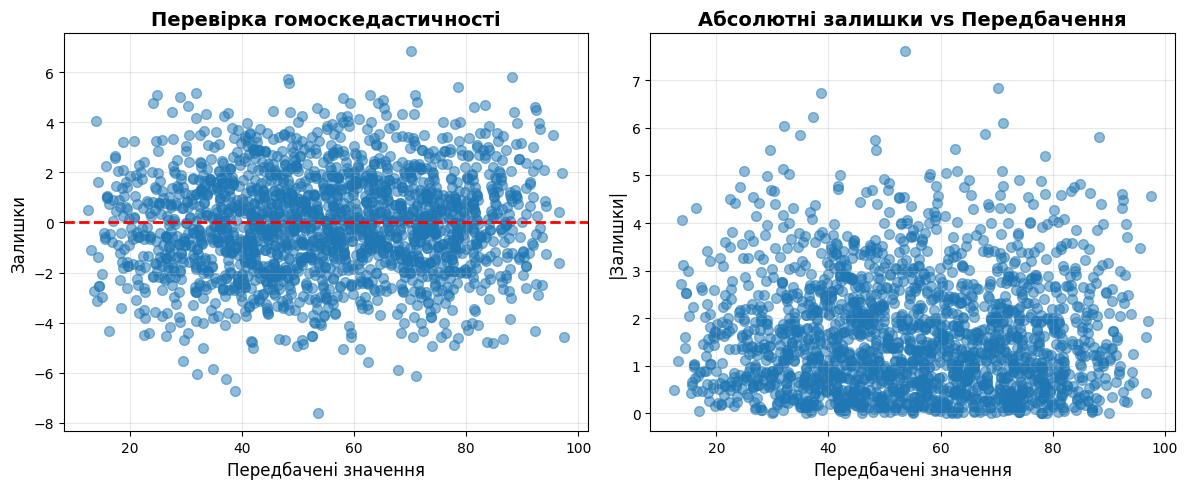


 Відношення дисперсій (макс/мін): 1.0305
    Гомоскедастичність виконується (відношення < 3)

 ПРИПУЩЕННЯ ВІДСУТНОСТІ АВТОКОРЕЛЯЦІЇ
------------------------------------------------------------

 Тест Дарбіна-Вотсона:
   Статистика: 2.0472
   Інтерпретація:
    Автокореляція відсутня (DW ≈ 2.0)


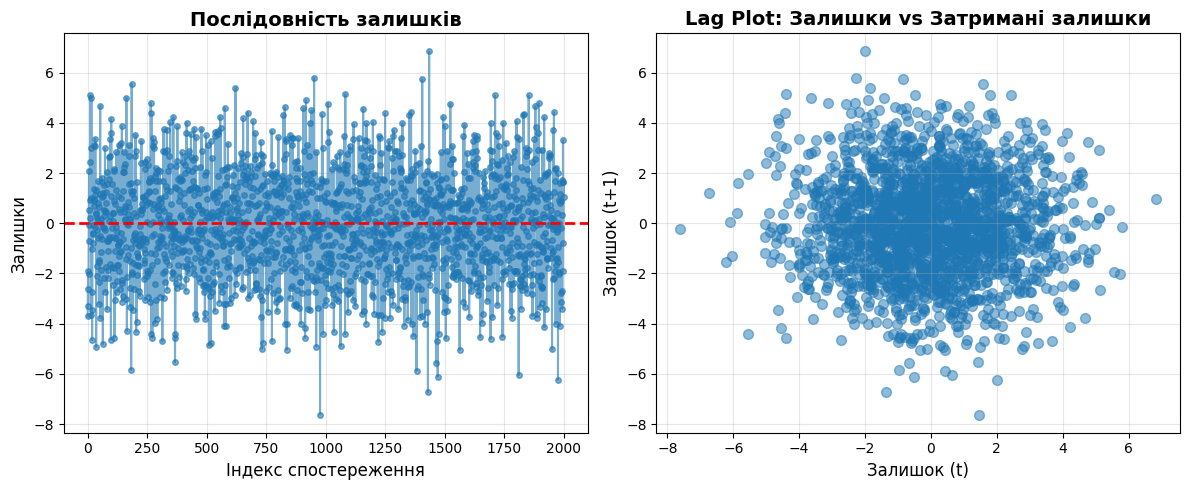


 ПРИПУЩЕННЯ ВІДСУТНОСТІ ВИКИДІВ ТА ВПЛИВОВИХ СПОСТЕРЕЖЕНЬ
------------------------------------------------------------

 Аналіз викидів (стандартизовані залишки > 3):
   Кількість викидів: 5 (0.25%)

 Аналіз впливових спостережень (Cook's D > 0.0020):
   Кількість впливових: 101 (5.05%)


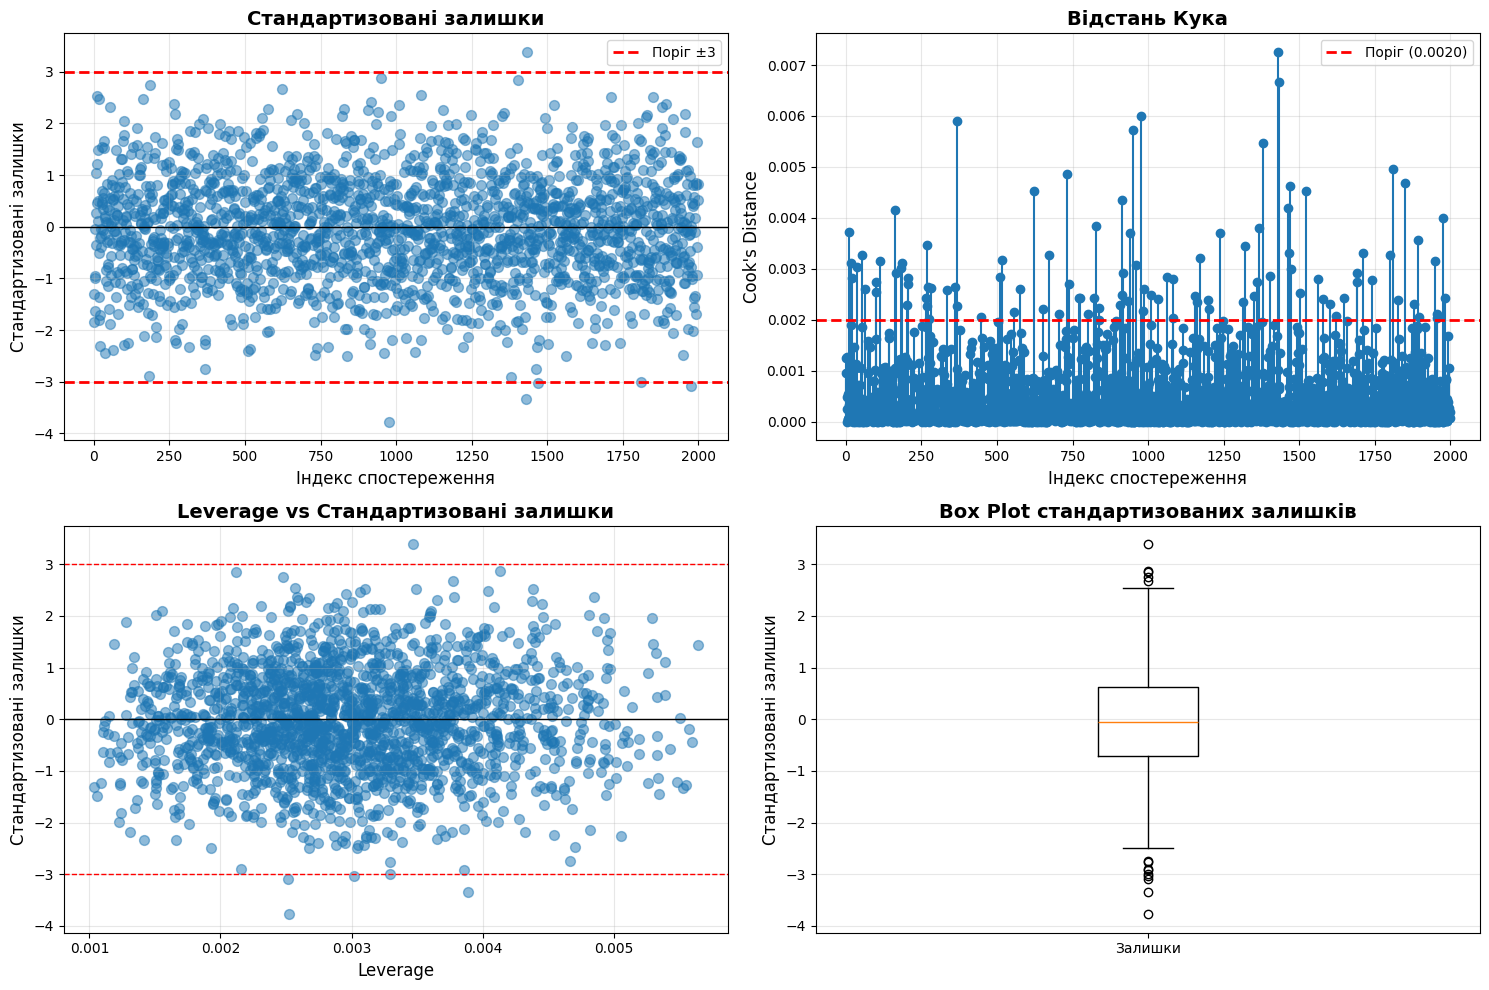

    Виявлено викиди
    Виявлено впливові спостереження

ЗАГАЛЬНИЙ ВИСНОВОК

 РЕЗУЛЬТАТИ МОДЕЛІ:
   • R² на тестовій вибірці: 0.9890
   • RMSE: 2.0206
   • Покращення над бейзлайном: 98.90%

 ПЕРЕВІРКА ПРИПУЩЕНЬ МНК:
   1. Лінійність: ✓
   2. Відсутність мультиколінеарності: ✓
   3. Нормальність залишків: ✓
   4. Гомоскедастичність: ✓
   5. Відсутність автокореляції: ✓
   6. Відсутність викидів: ✓

 ІНТЕРПРЕТАЦІЯ:
   • Модель має високу якість прогнозування (R² > 0.7)

   • Виконано 6/6 припущень МНК
   •  Модель є надійною та може використовуватись для прогнозування

 РЕКОМЕНДАЦІЇ:

 АНАЛІЗ ЗАВЕРШЕНО

 Зведена таблиця метрик:
    Метрика  Значення
MSE (Train)  4.169736
 MSE (Test)  4.082628
RMSE (Test)  2.020552
 MAE (Test)  1.611121
 R² (Train)  0.988690
  R² (Test)  0.988983

 Всі графіки збережено у поточній директорії:


In [27]:
# Візуалізація VIF
plt.figure(figsize=(10, 6))
plt.barh(vif_df['Ознака'], vif_df['VIF'], color='skyblue', edgecolor='black')
plt.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='Поріг (VIF=5)')
plt.axvline(x=10, color='red', linestyle='--', linewidth=2, label='Критичний поріг (VIF=10)')
plt.xlabel('VIF', fontsize=12)
plt.ylabel('Ознака', fontsize=12)
plt.title('Variance Inflation Factor для ознак', fontsize=14, weight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('vif_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ПРИПУЩЕННЯ 3: Нормальність залишків
print("\n ПРИПУЩЕННЯ НОРМАЛЬНОСТІ ЗАЛИШКІВ")
print("-" * 60)

plt.figure(figsize=(12, 5))

# Q-Q plot
plt.subplot(1, 2, 1)
probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot залишків', fontsize=14, weight='bold')
plt.grid(True, alpha=0.3)

# Гістограма з нормальною кривою
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, density=True, alpha=0.7, edgecolor='black')
mu, sigma = residuals.mean(), residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Нормальний розподіл')
plt.xlabel('Залишки', fontsize=12)
plt.ylabel('Щільність', fontsize=12)
plt.title('Гістограма залишків з нормальною кривою', fontsize=14, weight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('normality_check.png', dpi=300, bbox_inches='tight')
plt.show()

# Тест Шапіро-Вілка
shapiro_stat, shapiro_p = shapiro(residuals)
print(f"\n Тест Шапіро-Вілка:")
print(f"   Статистика: {shapiro_stat:.6f}")
print(f"   p-value:    {shapiro_p:.6f}")
print(f"   {' Залишки мають нормальний розподіл (p > 0.05)' if shapiro_p > 0.05 else ' Залишки можуть не мати нормального розподілу (p ≤ 0.05)'}")

# ПРИПУЩЕННЯ 4: Гомоскедастичність
print("\n ПРИПУЩЕННЯ ГОМОСКЕДАСТИЧНОСТІ")
print("-" * 60)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_test, residuals, alpha=0.5, s=50)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Передбачені значення', fontsize=12)
plt.ylabel('Залишки', fontsize=12)
plt.title('Перевірка гомоскедастичності', fontsize=14, weight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_pred_test, np.abs(residuals), alpha=0.5, s=50)
plt.xlabel('Передбачені значення', fontsize=12)
plt.ylabel('|Залишки|', fontsize=12)
plt.title('Абсолютні залишки vs Передбачення', fontsize=14, weight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('homoscedasticity_check.png', dpi=300, bbox_inches='tight')
plt.show()

# Перевірка зростання дисперсії
sorted_indices = np.argsort(y_pred_test)
n_groups = 3
group_size = len(residuals) // n_groups
variances = []
for i in range(n_groups):
    start = i * group_size
    end = (i + 1) * group_size if i < n_groups - 1 else len(residuals)
    group_residuals = residuals[sorted_indices[start:end]]
    variances.append(np.var(group_residuals))

variance_ratio = max(variances) / min(variances)
print(f"\n Відношення дисперсій (макс/мін): {variance_ratio:.4f}")
print(f"   {' Гомоскедастичність виконується (відношення < 3)' if variance_ratio < 3 else ' Можлива гетероскедастичність (відношення ≥ 3)'}")

# ПРИПУЩЕННЯ 5: Відсутність автокореляції
print("\n ПРИПУЩЕННЯ ВІДСУТНОСТІ АВТОКОРЕЛЯЦІЇ")
print("-" * 60)

# Тест Дарбіна-Вотсона
def durbin_watson(residuals):
    """Розрахунок статистики Дарбіна-Вотсона"""
    diff_residuals = np.diff(residuals)
    dw = np.sum(diff_residuals ** 2) / np.sum(residuals ** 2)
    return dw

dw_stat = durbin_watson(residuals)
print(f"\n Тест Дарбіна-Вотсона:")
print(f"   Статистика: {dw_stat:.4f}")
print(f"   Інтерпретація:")
if 1.5 < dw_stat < 2.5:
    print(f"    Автокореляція відсутня (DW ≈ 2.0)")
elif dw_stat <= 1.5:
    print(f"    Можлива позитивна автокореляція (DW < 1.5)")
else:
    print(f"    Можлива негативна автокореляція (DW > 2.5)")

# Графік автокореляції
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(residuals, marker='o', markersize=4, linestyle='-', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Індекс спостереження', fontsize=12)
plt.ylabel('Залишки', fontsize=12)
plt.title('Послідовність залишків', fontsize=14, weight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(residuals[:-1], residuals[1:], alpha=0.5, s=50)
plt.xlabel('Залишок (t)', fontsize=12)
plt.ylabel('Залишок (t+1)', fontsize=12)
plt.title('Lag Plot: Залишки vs Затримані залишки', fontsize=14, weight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('autocorrelation_check.png', dpi=300, bbox_inches='tight')
plt.show()

# ПРИПУЩЕННЯ 6: Відсутність викидів та впливових спостережень
print("\n ПРИПУЩЕННЯ ВІДСУТНОСТІ ВИКИДІВ ТА ВПЛИВОВИХ СПОСТЕРЕЖЕНЬ")
print("-" * 60)

# Стандартизовані залишки
standardized_residuals = residuals / np.std(residuals)
outliers = np.abs(standardized_residuals) > 3
n_outliers = np.sum(outliers)

print(f"\n Аналіз викидів (стандартизовані залишки > 3):")
print(f"   Кількість викидів: {n_outliers} ({n_outliers/len(residuals)*100:.2f}%)")

# Cook's Distance
def cooks_distance(X, residuals):
    """Розрахунок відстані Кука"""
    n, p = X.shape
    mse = np.mean(residuals ** 2)
    
    # Leverage (hat values)
    H = X.dot(np.linalg.inv(X.T.dot(X))).dot(X.T)
    h = np.diag(H)
    
    # Cook's distance
    cooks_d = (residuals ** 2) / (p * mse) * (h / (1 - h) ** 2)
    return cooks_d, h

cooks_d, leverage = cooks_distance(X_test_final, residuals)
threshold = 4 / len(residuals)
influential = cooks_d > threshold
n_influential = np.sum(influential)

print(f"\n Аналіз впливових спостережень (Cook's D > {threshold:.4f}):")
print(f"   Кількість впливових: {n_influential} ({n_influential/len(residuals)*100:.2f}%)")

# Візуалізація
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.scatter(range(len(residuals)), standardized_residuals, alpha=0.5, s=50)
plt.axhline(y=3, color='r', linestyle='--', linewidth=2, label='Поріг ±3')
plt.axhline(y=-3, color='r', linestyle='--', linewidth=2)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('Індекс спостереження', fontsize=12)
plt.ylabel('Стандартизовані залишки', fontsize=12)
plt.title('Стандартизовані залишки', fontsize=14, weight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.stem(range(len(cooks_d)), cooks_d, basefmt=' ')
plt.axhline(y=threshold, color='r', linestyle='--', linewidth=2, label=f"Поріг ({threshold:.4f})")
plt.xlabel('Індекс спостереження', fontsize=12)
plt.ylabel("Cook's Distance", fontsize=12)
plt.title("Відстань Кука", fontsize=14, weight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.scatter(leverage, standardized_residuals, alpha=0.5, s=50)
plt.axhline(y=3, color='r', linestyle='--', linewidth=1)
plt.axhline(y=-3, color='r', linestyle='--', linewidth=1)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('Leverage', fontsize=12)
plt.ylabel('Стандартизовані залишки', fontsize=12)
plt.title('Leverage vs Стандартизовані залишки', fontsize=14, weight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.boxplot([standardized_residuals], labels=['Залишки'])
plt.ylabel('Стандартизовані залишки', fontsize=12)
plt.title('Box Plot стандартизованих залишків', fontsize=14, weight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outliers_influential_check.png', dpi=300, bbox_inches='tight')
plt.show()

if n_outliers > 0:
    print(f"    Виявлено викиди")
if n_influential > 0:
    print(f"    Виявлено впливові спостереження")

# ==================== 7. ПІДСУМОК ====================
print("\n" + "=" * 80)
print("ЗАГАЛЬНИЙ ВИСНОВОК")
print("=" * 80)

print(f"\n РЕЗУЛЬТАТИ МОДЕЛІ:")
print(f"   • R² на тестовій вибірці: {r2_test:.4f}")
print(f"   • RMSE: {rmse_test:.4f}")
print(f"   • Покращення над бейзлайном: {improvement:.2f}%")

print(f"\n ПЕРЕВІРКА ПРИПУЩЕНЬ МНК:")
print(f"   1. Лінійність: {'✓' if abs(residual_pattern) < 0.01 else '⚠'}")
print(f"   2. Відсутність мультиколінеарності: {'✓' if max(vif_values) < 5 else '⚠'}")
print(f"   3. Нормальність залишків: {'✓' if shapiro_p > 0.05 else '⚠'}")
print(f"   4. Гомоскедастичність: {'✓' if variance_ratio < 3 else '⚠'}")
print(f"   5. Відсутність автокореляції: {'✓' if 1.5 < dw_stat < 2.5 else '⚠'}")
print(f"   6. Відсутність викидів: {'✓' if n_outliers < len(residuals)*0.05 else '⚠'}")

print(f"\n ІНТЕРПРЕТАЦІЯ:")
if r2_test > 0.7:
    print(f"   • Модель має високу якість прогнозування (R² > 0.7)")
elif r2_test > 0.5:
    print(f"   • Модель має прийнятну якість прогнозування (R² > 0.5)")
else:
    print(f"   • Модель має низьку якість прогнозування (R² ≤ 0.5)")

assumptions_passed = sum([
    abs(residual_pattern) < 0.01,
    max(vif_values) < 5,
    shapiro_p > 0.05,
    variance_ratio < 3,
    1.5 < dw_stat < 2.5,
    n_outliers < len(residuals)*0.05
])

print(f"\n   • Виконано {assumptions_passed}/6 припущень МНК")
if assumptions_passed >= 5:
    print(f"   •  Модель є надійною та може використовуватись для прогнозування")
elif assumptions_passed >= 3:
    print(f"   •  Модель має обмеження, результати слід інтерпретувати обережно")
else:
    print(f"   •  Модель має суттєві порушення припущень, розгляньте альтернативні підходи")

print(f"\n РЕКОМЕНДАЦІЇ:")
if max(vif_values) >= 5:
    print(f"   • Розгляньте видалення корельованих ознак або використання regularization (Ridge/Lasso)")
if shapiro_p <= 0.05:
    print(f"   • Розгляньте трансформацію цільової змінної (log, sqrt) для покращення нормальності")
if variance_ratio >= 3:
    print(f"   • Використайте Weighted Least Squares або трансформацію змінних для усунення гетероскедастичності")
if n_outliers > len(residuals)*0.05:
    print(f"   • Проаналізуйте викиди та розгляньте їх видалення або використання robust regression")
if r2_test < 0.5:
    print(f"   • Додайте нові ознаки або розгляньте нелінійні моделі (поліноміальна регресія, дерева рішень)")

print("\n" + "=" * 80)
print(" АНАЛІЗ ЗАВЕРШЕНО")
print("=" * 80)

# Створення зведеної таблиці результатів
summary_df = pd.DataFrame({
    'Метрика': ['MSE (Train)', 'MSE (Test)', 'RMSE (Test)', 'MAE (Test)', 'R² (Train)', 'R² (Test)'],
    'Значення': [mse_train, mse_test, rmse_test, mae_test, r2_train, r2_test]
})

print("\n Зведена таблиця метрик:")
print(summary_df.to_string(index=False))

# Збереження фінальних результатів
print("\n Всі графіки збережено у поточній директорії:")